In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

IMEI: 869487064492787

In [2]:
#01072026_11092026
raw_data=pd.read_excel(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\cea\ein621_01072026_11092026.xlsx')
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 37326 entries, 0 to 37325
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  37326 non-null  str  
 1   Message  37326 non-null  str  
 2   Status   37326 non-null  str  
dtypes: str(3)
memory usage: 875.0 KB


In [3]:
aux=pd.DataFrame()
aux=raw_data
aux['Headers']='NaN'

for i in range(0,aux.shape[0]):
    aux.iloc[i,3]=aux.iloc[i,2][0:8]

aux['Headers'].value_counts()

Headers
0x252513    35640
0x252514     1530
0x252501       82
0x252511       74
Name: count, dtype: int64

In [4]:
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 37326 entries, 0 to 37325
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  37326 non-null  str  
 1   Message  37326 non-null  str  
 2   Status   37326 non-null  str  
 3   Headers  37326 non-null  str  
dtypes: str(4)
memory usage: 1.1 MB


Odometer

In [5]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
unit_aux['Odometer in meters']=0.0
odometer=[]
date=[]
raw=[]
unit=pd.DataFrame()

for i in range(0,unit_aux.shape[0]):
    odometer.append(int(unit_aux.iloc[i,2][96:104],16))
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

unit_aux['Odometer in meters']=odometer
unit_aux['Date']=date
unit_aux['Raw data']=raw

#print(unit_aux['Odometer in meters'])

unit=unit_aux.sort_values('Date',ascending=True)

print(unit.info())

<class 'pandas.DataFrame'>
Index: 37170 entries, 10799 to 37325
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Created             37170 non-null  str  
 1   Message             37170 non-null  str  
 2   Status              37170 non-null  str  
 3   Headers             37170 non-null  str  
 4   Odometer in meters  37170 non-null  int64
 5   Date                37170 non-null  str  
 6   Raw data            37170 non-null  str  
dtypes: int64(1), str(6)
memory usage: 2.3 MB
None


000101000004 -> 0 -> 12520831.0 -> 0x25251400590CAB0869487064492787003C38402D00000000EC00000007000061000000FFFFFFFFFFFFFFFFFFFF168000BF0D7F000001010000040080C544223797C2938EC7400000006B03951388FFFFFF000035FFFFFFFFFF
000101000005 -> 1 -> 12039851.0 -> 0x25251400590C150869487064492787003C38402D00000000E400000007000061000000FFFFFFFFFFFFFFFFFFFF168000B7B6AB0000010100000533C3C044EF3397C2FCF7C740000000F403951410FFFFFF00001DFFFFFFFFFF
000101000005 -> 2 -> 12439670.0 -> 0x25251400590C870869487064492787003C38402D00000000E600000007000061000000FFFFFFFFFFFFFFFFFFFF168000BDD076000001010000053383AA44FD3397C2BCFBC7400000004503961398FFFFFF00001CFFFFFFFFFF
000101000005 -> 3 -> 12503464.0 -> 0x25251400590CA10869487064492787003C38402D00000000E400000007000061000000FFFFFFFFFFFFFFFFFFFF168000BEC9A80000010100000566968244F13297C2FF03C8400000003703951391FFFFFF00001EFFFFFFFFFF
000101000005 -> 4 -> 12503731.0 -> 0x25251400590CA30869487064492787003C38402D00000000EA00000007000061000000FFFFFFFFFFFFFFFFFFFF168000BEC

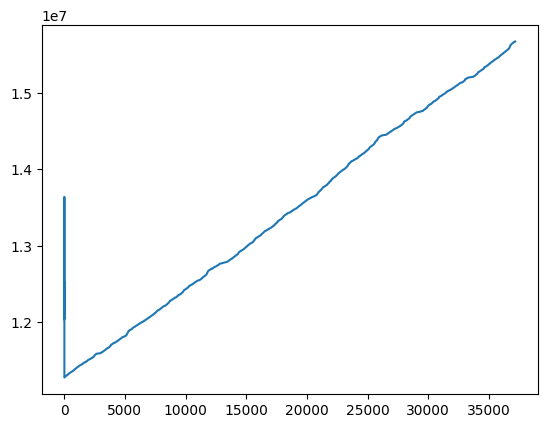

In [6]:
y_axis=[]
x_axis=[]
date=[]
raw_data_=[]

for i in range(0,unit.shape[0]):
    #print(float(fsq694_m_odometer.iloc[i,6][8:15]))
    y_axis.append(float(unit.iloc[i,4]))
    x_axis.append(i)
    date.append(unit.iloc[i,5])
    raw_data_.append(unit.iloc[i,6])

#print("Delta odometer: ",y_axis[170]-y_axis[133],'meters')

for i in range(0,len(odometer)):
    print(date[i],'->',x_axis[i],'->',y_axis[i],'->',raw_data_[i])

#print(odometer[len(odometer)-1]-odometer[0])
plt.plot(x_axis,y_axis)

In [7]:
y_axis_sr=[]
x_axis_sr=[]
date_sr=[]
raw_data_sr=[]
speed_sr=[]
bottom_lim=12703240-300
upper_lim=12703240+300
unit.info()

for i in range(0,unit.shape[0]):
    #print(unit.iloc[i,4],'->',bottom_lim,'->',upper_lim)
    if unit.iloc[i,4]>bottom_lim and unit.iloc[i,4]<upper_lim:
        y_axis_sr.append(float(unit.iloc[i,4]))
        x_axis_sr.append(i)
        date_sr.append(unit.iloc[i,3])
        raw_data_sr.append(unit.iloc[i,2])
        speed_sr.append(int(unit.iloc[i,2][142:145]))  
        print(bottom_lim,'->',unit.iloc[i,4],'->',upper_lim,'->',unit.iloc[i,2][142:145])

report_highspeed_sr=pd.DataFrame()
report_highspeed_sr['Date']=date_sr
report_highspeed_sr['Raw data']=raw_data_sr
report_highspeed_sr['Speed']=speed_sr
report_highspeed_sr['odometer']=y_axis_sr

report_highspeed_sr.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\cea\869487064492787_2.csv')

<class 'pandas.DataFrame'>
Index: 37170 entries, 10799 to 37325
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Created             37170 non-null  str  
 1   Message             37170 non-null  str  
 2   Status              37170 non-null  str  
 3   Headers             37170 non-null  str  
 4   Odometer in meters  37170 non-null  int64
 5   Date                37170 non-null  str  
 6   Raw data            37170 non-null  str  
dtypes: int64(1), str(6)
memory usage: 2.3 MB
12702940 -> 12702944 -> 12703540 -> 012
12702940 -> 12702971 -> 12703540 -> 013
12702940 -> 12702999 -> 12703540 -> 029
12702940 -> 12703086 -> 12703540 -> 016
12702940 -> 12703092 -> 12703540 -> 028
12702940 -> 12703104 -> 12703540 -> 033
12702940 -> 12703240 -> 12703540 -> 125
12702940 -> 12703361 -> 12703540 -> 018
12702940 -> 12703408 -> 12703540 -> 018
12702940 -> 12703434 -> 12703540 -> 010
12702940 -> 12703453 -> 12703540 ->

Speed

In [8]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
#unit_aux['Odometer in meters']=0.0
speed=[]
date=[]
raw=[]
unit_speed=pd.DataFrame()
unit=pd.DataFrame()

for i in range(0,unit_aux.shape[0]):
    try:
        lbs_ind=(bin(int(unit_aux.iloc[i,2][50:52],16) & 64))
        if lbs_ind=='0b1000000':
            speed.append(int(unit_aux.iloc[i,2][142:145]))  
            date.append(unit_aux.iloc[i,2][106:118])
            raw.append(unit_aux.iloc[i,2])
            #print(lbs_ind)
    except:
        pass 
    
unit_speed['Speed']=speed
unit_speed['Date']=date
unit_speed['Raw data']=raw

unit=unit_speed.sort_values('Date',ascending=True)

print(unit.info())

<class 'pandas.DataFrame'>
Index: 36974 entries, 35909 to 36973
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Speed     36974 non-null  int64
 1   Date      36974 non-null  str  
 2   Raw data  36974 non-null  str  
dtypes: int64(1), str(2)
memory usage: 1.1 MB
None


260702095236 -> 842 -> 173.0 -> 0x25251300596B580869487064492787003C38402D0000005D4500000007000020000000FFFFFFFFFFFFFFFFFFFF00D500ADB2CC8926070209523666A6BE44233397C2FC05C8401730002A03871328FFFFFF0000210006FFFFFF
260703051526 -> 1648 -> 103.0 -> 0x25251300596E660869487064492787003C38402D000000414700000007000020000000FFFFFFFFFFFFFFFFFFFF00D500AF19CF912607030515269AB9C844333497C23601C8401030013C03871288FFFFFF0000220003FFFFFF
260725022208 -> 12107 -> 97.0 -> 0x252513005995870869487064492787003C38402D0000003E4500000007000020000000FFFFFFFFFFFFFFFFFFFF00D500C1BC9B922607250222086646C0443F3297C2BCDCC7400970013D03881270FFFFFF0000260008FFFFFF
260725051751 -> 12143 -> 125.0 -> 0x252513005995AB0869487064492787003C38402D0000003A4500000007000020000000FFFFFFFFFFFFFFFFFFFF00D500C1D608902607250517510000BC44D33397C26CECC7401250009903871261FFFFFF0000210005FFFFFF
260726093309 -> 13062 -> 91.0 -> 0x252513005999290869487064492787003C38402D000000374700000007000020000000FFFFFFFFFFFFFFFFFFFF00D500C2F4CA8926072

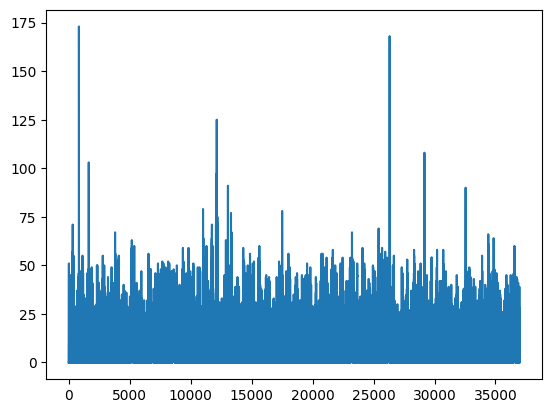

In [9]:
y_axis=[]
x_axis=[]
date=[]
raw_data_=[]
date_report=[]
x_axis_report=[]
y_axis_report=[]
raw_data_report=[]
report_higspeed=pd.DataFrame()

for i in range(0,unit.shape[0]):
    #print(float(fsq694_m_odometer.iloc[i,6][8:15]))
    y_axis.append(float(unit.iloc[i,0]))
    x_axis.append(i)
    date.append(unit.iloc[i,1])
    raw_data_.append(unit.iloc[i,2])
    #print(raw_data_[i])
    
for i in range(0,len(speed)):
    if (y_axis[i]>90):
        date_report.append(date[i])
        x_axis_report.append(x_axis[i])
        y_axis_report.append(y_axis[i])
        raw_data_report.append(raw_data_[i])
        print(date[i],'->',x_axis[i],'->',y_axis[i],'->',raw_data_[i])

report_higspeed['Date']=date_report
report_higspeed['Index']=x_axis_report
report_higspeed['Speed']=y_axis_report  
report_higspeed['Raw data']=raw_data_report

report_higspeed.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\cea\EIN621_2_highspeed.csv')
plt.plot(x_axis,y_axis)

In [10]:
max(y_axis)

173.0

Satellites

In [11]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
satellite_number=[]
satellite_connection_indicator=[]
date=[]
raw=[]
num_events=0

for i in range(0,unit_aux.shape[0]):
    satellite_number.append(int(unit_aux.iloc[i,2][50:52],16) & 31)
    satellite_connection_indicator.append(int(unit_aux.iloc[i,2][50:52],16) & 128)
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

unit_aux['Satellites']=satellite_number
unit_aux['Satellite_connection_indicator']=satellite_connection_indicator
unit_aux['Raw data']=raw
unit_aux['date']=date

unit=unit_aux.sort_values('date',ascending=True)
unit.info()

for i in range(0,unit.shape[0]):
    if unit.iloc[i,4]<1:
        num_events=num_events+1
        print(unit.iloc[i,0], '->',unit.iloc[i,4],'->',unit.iloc[i,5],'->',unit.iloc[i,6])

print("Eventos históricos: ",num_events)

<class 'pandas.DataFrame'>
Index: 37170 entries, 10799 to 37325
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   Created                         37170 non-null  str  
 1   Message                         37170 non-null  str  
 2   Status                          37170 non-null  str  
 3   Headers                         37170 non-null  str  
 4   Satellites                      37170 non-null  int64
 5   Satellite_connection_indicator  37170 non-null  int64
 6   Raw data                        37170 non-null  str  
 7   date                            37170 non-null  str  
dtypes: int64(2), str(6)
memory usage: 2.6 MB
2026-07-01 03:28:52.442 -> 0 -> 0 -> 0x2525130059682F0869487064492787003C38402D000000300000000007000020000000FFFFFFFFFFFFFFFFFFFF00D500AC240B9126070103303082DC00650800876561B6005400E900FC03871300FFFFFF000024FFFFFFFFFF
2026-07-01 07:29:52.969 -> 0 -> 0 -> 0x25251300596

In/Outs

15      14                 13      12      11      10      09      08       07 06 05 04 03 02 01 00
Power   Ignition/Input0    Input1  Input2  Input3  Input4  Input5  Input0

15=0, Connected
15=1. Disconnected

In [12]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
unit_aux.info()
aux_cad=[]
aux_date=[]
aux_raw_data=[]
aux_input_number=[]
in_outs=[]

#unit_aux.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\sym\concatenated.csv')

for i in range(0,unit_aux.shape[0]):
    long_cad=len(unit_aux.iloc[i,2])
    if ((long_cad>48) & (long_cad<204)):
        aux_cad.append(unit_aux.iloc[i,2])   

for i in range(0,len(aux_cad)):
    aux_value=aux_cad[i][64:68]
    aux_date.append(aux_cad[i][106:118])
    aux_raw_data.append(aux_cad[i])
    in_outs.append(bin (int (aux_cad[i][64:68],16)))      

unit_=pd.DataFrame()
unit_['in and outs']=in_outs
unit_['date']=aux_date
unit_['raw data']=aux_raw_data

in_outs_df=unit_.sort_values('date',ascending=True)

#in_outs_df.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\sym\in_outs.csv')

<class 'pandas.DataFrame'>
Index: 37170 entries, 0 to 37325
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  37170 non-null  str  
 1   Message  37170 non-null  str  
 2   Status   37170 non-null  str  
 3   Headers  37170 non-null  str  
dtypes: str(4)
memory usage: 1.4 MB


Power

In [13]:
ext_bat_13=raw_data[raw_data['Status'].str.contains('0x252513')]
ext_bat_14=raw_data[raw_data['Status'].str.contains('0x252514')]
ext_bat_vol=pd.concat([ext_bat_13,ext_bat_14])
ext_bat=[]
date_bat=[]
bat_df=pd.DataFrame()

ext_bat_vol.info()

for i in range(0,ext_bat_vol.shape[0]):
    val=(float(ext_bat_vol.iloc[i,2][154:158]))/100
    date_bat.append(ext_bat_vol.iloc[i,2][106:119])
    ext_bat.append(val)
#print(ext_bat)

for i in range(0,ext_bat_vol.shape[0]):
    if ext_bat[i]<3:
        bat_df['Date']=date_bat
        bat_df['int_bat']=ext_bat

print(bat_df)

<class 'pandas.DataFrame'>
Index: 37170 entries, 0 to 37325
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  37170 non-null  str  
 1   Message  37170 non-null  str  
 2   Status   37170 non-null  str  
 3   Headers  37170 non-null  str  
dtypes: str(4)
memory usage: 1.4 MB
                Date  int_bat
0      2607010330308    13.00
1      2607010730308    12.87
2      2607011047340    14.32
3      260701104753C    14.35
4      2607011048009    14.35
...              ...      ...
37165  2609112248269    12.80
37166  2609112248399    12.69
37167  2609112313519    12.81
37168  2609112354409    13.72
37169  2609112359579    12.48

[37170 rows x 2 columns]


Pánico

In [14]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
unit_aux.info()
aux_cad=[]
aux_date=[]
aux_raw_data=[]
aux_input_number=[]

#unit_aux.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\sym\concatenated.csv')

for i in range(0,unit_aux.shape[0]):
    long_cad=len(unit_aux.iloc[i,2])
    if ((long_cad>48) & (long_cad<204)):
        aux_cad.append(unit_aux.iloc[i,2])   

for i in range(0,len(aux_cad)):
    aux_value=aux_cad[i][64:68]
    aux_date.append(aux_cad[i][106:118])
    #aux_raw_data.append(aux_cad[i])
    if aux_value=='03':
        print(aux_value, ' -> ',aux_date[i])    

print("len aux_cad: ",len(aux_cad))

<class 'pandas.DataFrame'>
Index: 37170 entries, 0 to 37325
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  37170 non-null  str  
 1   Message  37170 non-null  str  
 2   Status   37170 non-null  str  
 3   Headers  37170 non-null  str  
dtypes: str(4)
memory usage: 1.4 MB
len aux_cad:  37170
